<a href="https://colab.research.google.com/github/Nikita1532001/real-time-project/blob/main/gold_silver_prediction_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gold & Silver Price Prediction Project
## Real-Time Data Science Project using Kaggle Dataset, XGBoost, and LSTM

This project includes:
- Kaggle Dataset Analysis
- Data Cleaning
- EDA
- XGBoost Model
- LSTM Deep Learning
- Real-Time Gold & Silver Data
- Buy/Sell Signals
- Streamlit Dashboard

## Install Required Libraries

In [8]:

!pip install pandas numpy matplotlib seaborn scikit-learn xgboost tensorflow yfinance plotly streamlit joblib


## Import Libraries

In [9]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

from sklearn.preprocessing import MinMaxScaler
from xgboost import XGBRegressor

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

import yfinance as yf
import plotly.express as px
import joblib


## Load Kaggle Dataset
Download datasets from Kaggle and upload them to Google Colab.

Dataset Links:
- Gold Price Dataset
- Silver Price Dataset

In [13]:
from google.colab import files

uploaded = files.upload()

Saving FINAL_USO.csv to FINAL_USO.csv


In [14]:
import pandas as pd

gold_df = pd.read_csv('FINAL_USO.csv')
silver_df = pd.read_csv('FINAL_USO.csv')

print(gold_df.head())

         Date        Open        High         Low       Close   Adj Close  \
0  2011-12-15  154.740005  154.949997  151.710007  152.330002  152.330002   
1  2011-12-16  154.309998  155.369995  153.899994  155.229996  155.229996   
2  2011-12-19  155.479996  155.860001  154.360001  154.869995  154.869995   
3  2011-12-20  156.820007  157.429993  156.580002  156.979996  156.979996   
4  2011-12-21  156.979996  157.529999  156.130005  157.160004  157.160004   

     Volume     SP_open     SP_high      SP_low  ...    GDX_Low  GDX_Close  \
0  21521900  123.029999  123.199997  121.989998  ...  51.570000  51.680000   
1  18124300  122.230003  122.949997  121.300003  ...  52.040001  52.680000   
2  12547200  122.059998  122.320000  120.029999  ...  51.029999  51.169998   
3   9136300  122.180000  124.139999  120.370003  ...  52.369999  52.990002   
4  11996100  123.930000  124.360001  122.750000  ...  52.419998  52.959999   

   GDX_Adj Close  GDX_Volume   USO_Open   USO_High    USO_Low  USO_C

## Data Cleaning

In [15]:

gold_df.dropna(inplace=True)
silver_df.dropna(inplace=True)

gold_df['Date'] = pd.to_datetime(gold_df['Date'])
silver_df['Date'] = pd.to_datetime(silver_df['Date'])

print(gold_df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1718 entries, 0 to 1717
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           1718 non-null   datetime64[ns]
 1   Open           1718 non-null   float64       
 2   High           1718 non-null   float64       
 3   Low            1718 non-null   float64       
 4   Close          1718 non-null   float64       
 5   Adj Close      1718 non-null   float64       
 6   Volume         1718 non-null   int64         
 7   SP_open        1718 non-null   float64       
 8   SP_high        1718 non-null   float64       
 9   SP_low         1718 non-null   float64       
 10  SP_close       1718 non-null   float64       
 11  SP_Ajclose     1718 non-null   float64       
 12  SP_volume      1718 non-null   int64         
 13  DJ_open        1718 non-null   float64       
 14  DJ_high        1718 non-null   float64       
 15  DJ_low         1718 n

## Exploratory Data Analysis

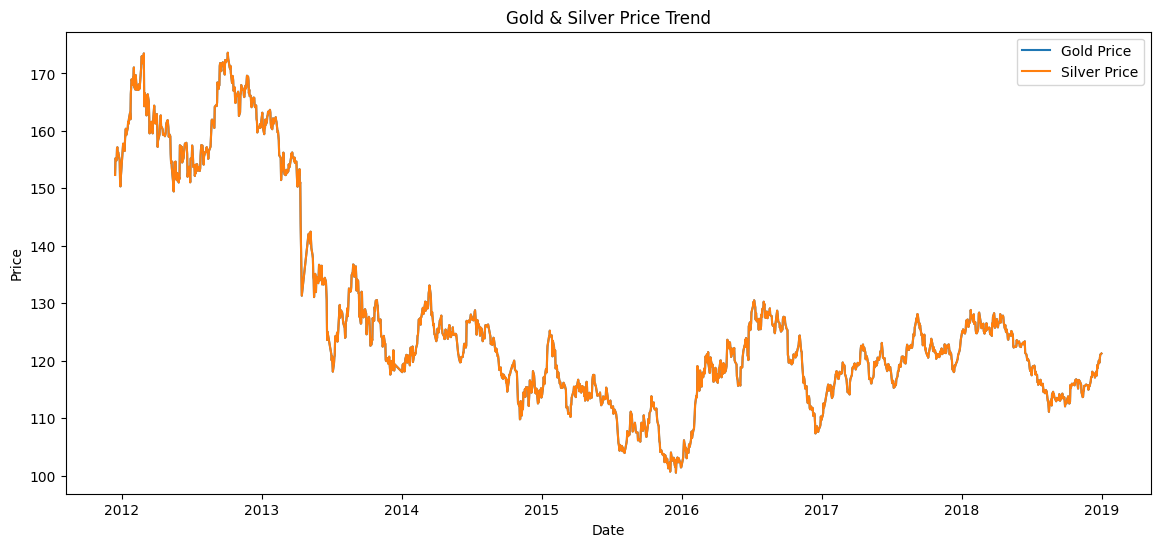

In [16]:

plt.figure(figsize=(14,6))

plt.plot(gold_df['Date'], gold_df['Close'], label='Gold Price')
plt.plot(silver_df['Date'], silver_df['Close'], label='Silver Price')

plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Gold & Silver Price Trend')

plt.legend()
plt.show()


## Feature Engineering

In [17]:

gold_df['MA10'] = gold_df['Close'].rolling(window=10).mean()
gold_df['MA50'] = gold_df['Close'].rolling(window=50).mean()

gold_df.dropna(inplace=True)

gold_df.head()


,Date,Open,High,Low,Close,Adj Close,Volume,SP_open,SP_high,SP_low,...,GDX_Adj Close,GDX_Volume,USO_Open,USO_High,USO_Low,USO_Close,USO_Adj Close,USO_Volume,MA10,MA50
49,2012-02-29,173.190002,173.589996,164.000000,164.289993,164.289993,44149000,137.759995,138.190002,136.539993,...,52.649803,34053800,40.849998,41.070000,40.099998,40.919998,40.919998,19797400,170.215001,162.9622
50,2012-03-01,166.100006,167.720001,165.750000,166.610001,166.610001,19200700,137.309998,137.990005,136.929993,...,53.115479,15032900,41.139999,42.299999,40.820000,41.750000,41.750000,24575900,170.065001,163.2478
51,2012-03-02,166.229996,166.830002,165.630005,166.339996,166.339996,9298100,137.639999,137.820007,137.000000,...,52.070087,12757700,41.279999,41.320000,40.480000,40.770000,40.770000,15442200,169.899000,163.4700
52,2012-03-05,165.770004,165.910004,164.550003,165.649994,165.649994,12071400,137.100006,137.199997,136.279999,...,50.958160,13539600,40.930000,40.990002,40.570000,40.970001,40.970001,7398900,169.728999,163.6856
53,2012-03-06,162.149994,162.809998,161.779999,162.699997,162.699997,15533200,135.350006,135.429993,134.360001,...,49.865253,20943600,40.099998,40.400002,39.970001,40.130001,40.130001,10091800,168.896998,163.8000


## Correlation Heatmap

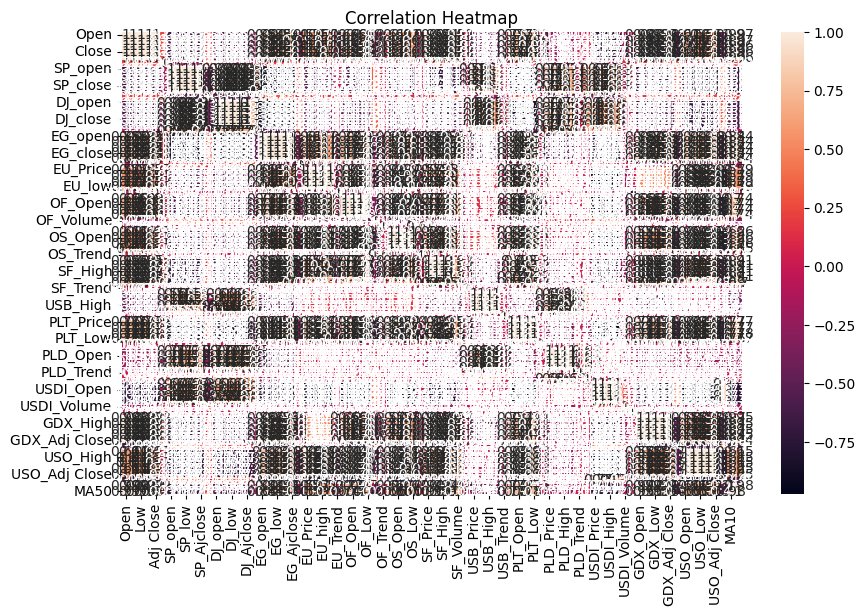

In [18]:

plt.figure(figsize=(10,6))

sns.heatmap(gold_df.corr(numeric_only=True), annot=True)

plt.title('Correlation Heatmap')
plt.show()


## Machine Learning Model - XGBoost

In [19]:

X = gold_df[['Open', 'High', 'Low', 'Volume']]
y = gold_df['Close']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5
)

xgb_model.fit(X_train, y_train)

predictions = xgb_model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("MAE:", mae)
print("RMSE:", rmse)


MAE: 0.3593186639280029
RMSE: 0.5631855652038686


## Actual vs Predicted

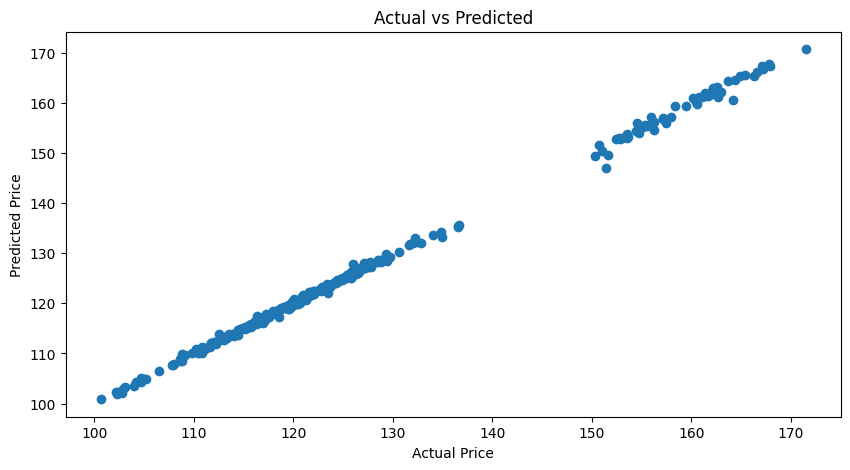

In [20]:

plt.figure(figsize=(10,5))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")

plt.show()


## Save XGBoost Model

In [21]:

joblib.dump(xgb_model, 'xgb_model.pkl')
print("Model Saved Successfully")


Model Saved Successfully


## Deep Learning Model - LSTM

In [22]:

data = gold_df['Close'].values.reshape(-1,1)

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

X_lstm = []
y_lstm = []

for i in range(60, len(scaled_data)):
    X_lstm.append(scaled_data[i-60:i,0])
    y_lstm.append(scaled_data[i,0])

X_lstm = np.array(X_lstm)
y_lstm = np.array(y_lstm)

X_lstm = np.reshape(
    X_lstm,
    (X_lstm.shape[0], X_lstm.shape[1], 1)
)

print(X_lstm.shape)


(1609, 60, 1)


In [23]:

lstm_model = Sequential()

lstm_model.add(
    LSTM(50, return_sequences=True,
         input_shape=(X_lstm.shape[1],1))
)

lstm_model.add(LSTM(50))

lstm_model.add(Dense(1))

lstm_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

lstm_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:

history = lstm_model.fit(
    X_lstm,
    y_lstm,
    epochs=10,
    batch_size=32
)


Epoch 1/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step - loss: 0.0100
Epoch 2/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - loss: 0.0015
Epoch 3/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 0.0014
Epoch 4/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - loss: 0.0012
Epoch 5/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - loss: 0.0011
Epoch 6/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - loss: 9.6562e-04
Epoch 7/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 9.1508e-04
Epoch 8/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 7s 94ms/step - loss: 8.6965e-04
Epoch 9/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 8.5525e-04
Epoch 10/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - loss: 8.0188e-04


## Save LSTM Model

In [25]:

lstm_model.save('gold_lstm_model.h5')

print("LSTM Model Saved")


LSTM Model Saved


## Buy / Sell Signal

In [26]:

gold_df['Signal'] = np.where(
    gold_df['MA10'] > gold_df['MA50'],
    'BUY',
    'SELL'
)

gold_df[['Date', 'Close', 'Signal']].tail()


,Date,Close,Signal
1713,2018-12-24,120.019997,BUY
1714,2018-12-26,119.660004,BUY
1715,2018-12-27,120.570000,BUY
1716,2018-12-28,121.059998,BUY
1717,2018-12-31,121.250000,BUY


## Real-Time Gold & Silver Data

In [27]:

gold_live = yf.download('GC=F', period='5d')
silver_live = yf.download('SI=F', period='5d')

print(gold_live.tail())
print(silver_live.tail())


/tmp/ipykernel_11550/3917717267.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  gold_live = yf.download('GC=F', period='5d')
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_11550/3917717267.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  silver_live = yf.download('SI=F', period='5d')
[*********************100%***********************]  1 of 1 completed

Price             Close         High          Low         Open Volume
Ticker             GC=F         GC=F         GC=F         GC=F   GC=F
Date                                                                 
2026-05-11  4718.700195  4729.500000  4718.700195  4729.500000     36
2026-05-12  4677.600098  4765.200195  4677.600098  4762.200195     93
2026-05-13  4697.700195  4722.700195  4679.500000  4722.700195     93
2026-05-14  4706.700195  4725.799805  4673.200195  4696.799805  43215
Price           Close       High        Low       Open Volume
Ticker           SI=F       SI=F       SI=F       SI=F   SI=F
Date                                                         
2026-05-11  85.485001  86.250000  85.000000  85.605003    408
2026-05-12  85.129997  86.910004  83.750000  86.495003    418
2026-05-13  88.888000  88.888000  86.930000  86.930000    418
2026-05-14  87.410004  89.165001  86.800003  88.125000  20906


## Real-Time Price Graph

In [31]:
fig = px.line(
    gold_live,
    x=gold_live.index,
    y='Close_GC=F',
    title='Real-Time Gold Price'
)

fig.show()

## Streamlit Dashboard Code

In [32]:

streamlit_code = '''
import streamlit as st
import yfinance as yf
import plotly.express as px

st.title("Gold & Silver Prediction Dashboard")

gold = yf.download("GC=F", period="1mo")
silver = yf.download("SI=F", period="1mo")

fig1 = px.line(gold, y=gold['Close'], title='Gold Price')
fig2 = px.line(silver, y=silver['Close'], title='Silver Price')

st.plotly_chart(fig1)
st.plotly_chart(fig2)

st.success("Real-Time Data Loaded")
'''

with open("streamlit_app.py", "w") as f:
    f.write(streamlit_code)

print("Streamlit App Created")


Streamlit App Created


## Run Streamlit Dashboard

In [33]:

# Run this in terminal

# streamlit run streamlit_app.py


## Project Completed

Outputs:
- Gold Price Prediction
- Silver Price Prediction
- XGBoost Model
- LSTM Deep Learning
- Buy/Sell Signals
- Real-Time Market Data
- Streamlit Dashboard